In [14]:
# For data handling
import pandas as pd
# For numerical operations
import numpy as np
# For plotting graphs
import matplotlib.pyplot as plt
# For advanced visualization
import seaborn as sns

In [20]:
# Upload CSV/Excel file from your local system to Google Colab
from google.colab import files
uploaded = files.upload()

Saving TASK-3 Dataset.xlsx to TASK-3 Dataset.xlsx


In [21]:
# Read the dataset into a pandas DataFrame
df = pd.read_excel('TASK-3 Dataset.xlsx')
# Display first 5 rows to understand structure
df.head()

,ID,Gender,DOB,Lead_Creation_Date,City_Code,City_Category,Employer_Code,Employer_Category1,Employer_Category2,Monthly_Income,...,Primary_Bank_Type,Contacted,Source,Source_Category,Existing_EMI,Loan_Amount,Loan_Period,Interest_Rate,EMI,Var1
0,APPA70109647212,Male,1988-03-06 00:00:00,2016-05-07 00:00:00,C10028,C,COM0002222,A,4.0,2150.0,...,P,Y,S122,B,0.0,10000.0,3.0,20.0,372.0,4
1,APPB10687939341,Male,13/07/81,2016-01-07 00:00:00,C10003,A,COM0001784,C,4.0,4200.0,...,P,Y,S133,C,0.0,69000.0,5.0,24.0,1985.0,7
2,APPC80449411414,Female,19/11/90,2016-01-07 00:00:00,C10009,B,COM0045260,B,4.0,1000.0,...,P,N,S133,B,0.0,NaN,NaN,NaN,NaN,0
3,APPD30665094501,Female,15/10/92,2016-01-07 00:00:00,C10005,A,COM0000085,A,3.0,1465.0,...,P,N,S133,C,0.0,NaN,NaN,NaN,NaN,0
4,APPE80379821637,Male,21/09/88,2016-01-07 00:00:00,C10005,A,COM0006422,A,4.0,2340.0,...,P,Y,S143,B,500.0,10000.0,2.0,NaN,NaN,0


In [22]:
# Check data types and null values
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30037 entries, 0 to 30036
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   30037 non-null  object 
 1   Gender                               30037 non-null  object 
 2   DOB                                  30034 non-null  object 
 3   Lead_Creation_Date                   30037 non-null  object 
 4   City_Code                            29723 non-null  object 
 5   City_Category                        29723 non-null  object 
 6   Employer_Code                        28432 non-null  object 
 7   Employer_Category1                   28432 non-null  object 
 8   Employer_Category2                   28342 non-null  float64
 9   Monthly_Income                       30037 non-null  float64
 10  Customer_Existing_Primary_Bank_Code  26000 non-null  object 
 11  Primary_Bank_Type           

,Employer_Category2,Monthly_Income,Existing_EMI,Loan_Amount,Loan_Period,Interest_Rate,EMI,Var1
count,28342.000000,3.003700e+04,30005.000000,18166.000000,18166.000000,9652.000000,9652.000000,30037.000000
mean,3.728248,3.977139e+03,348.909060,39482.990201,3.903116,19.280537,1094.914836,3.962313
std,0.794883,2.328960e+04,1000.816847,30527.865594,1.150820,5.882246,727.452303,3.821020
min,1.000000,0.000000e+00,0.000000,5000.000000,1.000000,11.990000,118.000000,0.000000
25%,4.000000,1.650000e+03,0.000000,20000.000000,3.000000,15.250000,625.000000,0.000000
50%,4.000000,2.500000e+03,0.000000,30000.000000,4.000000,18.000000,946.000000,2.000000
75%,4.000000,4.000000e+03,350.000000,50000.000000,5.000000,20.000000,1291.000000,7.000000
max,4.000000,3.500000e+06,43000.000000,300000.000000,6.000000,37.000000,6979.000000,10.000000


In [25]:
# DATA CLEANING
# Check missing values
df.isnull().sum()

# Remove missing values (if any)
df.dropna(inplace=True)

# Check duplicates
df.duplicated().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

In [28]:
#Renamed columns to simple names
df.columns = df.columns.str.strip()


In [29]:
print(df.columns)

Index(['ID', 'Gender', 'DOB', 'Lead_Creation_Date', 'City_Code',
       'City_Category', 'Employer_Code', 'Employer_Category1',
       'Employer_Category2', 'Monthly_Income',
       'Customer_Existing_Primary_Bank_Code', 'Primary_Bank_Type', 'Contacted',
       'Source', 'Source_Category', 'Existing_EMI', 'Loan_Amount',
       'Loan_Period', 'Interest_Rate', 'EMI', 'Var1'],
      dtype='object')


In [ ]:
#Creating Funnel Metrics
# Conversion Rates
df['Click_Rate'] = df['Clicks'] / df['Visitors']
df['Signup_Rate'] = df['Signups'] / df['Clicks']
df['Purchase_Rate'] = df['Purchases'] / df['Signups']

# Drop-off calculations
df['Drop_Click'] = df['Visitors'] - df['Clicks']
df['Drop_Signup'] = df['Clicks'] - df['Signups']
df['Drop_Purchase'] = df['Signups'] - df['Purchases']

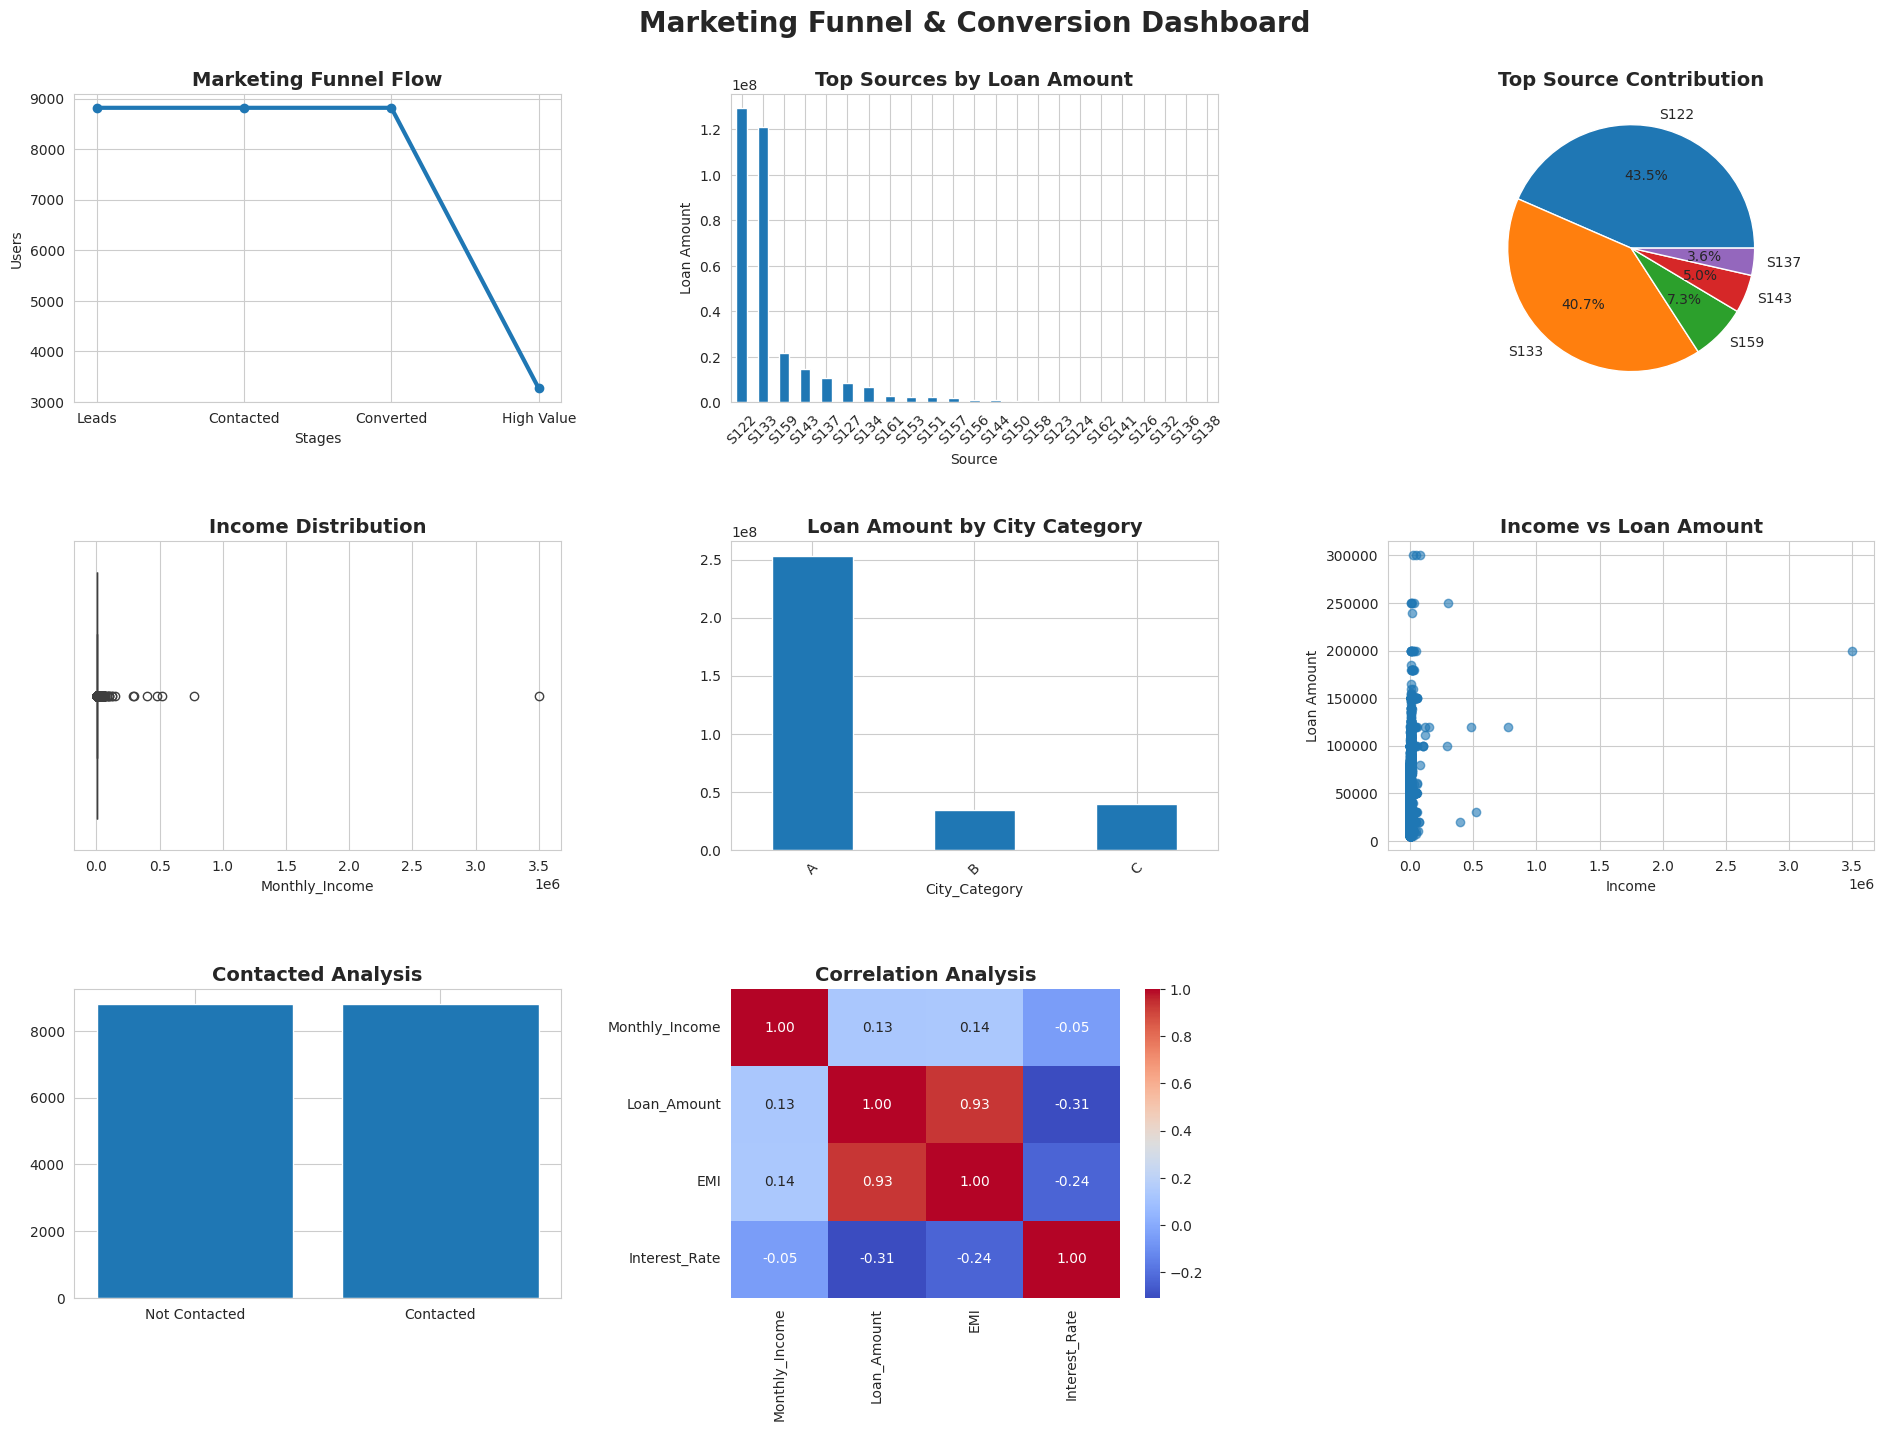

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# -------------------------------
# CREATE FUNNEL STAGES
# -------------------------------

# Total leads
total_leads = len(df)

# Contacted leads
contacted = df['Contacted'].notnull().sum()

# Converted leads (assuming loan taken if Loan_Amount > 0)
converted = df[df['Loan_Amount'] > 0].shape[0]

# High value customers
high_value = df[df['Loan_Amount'] > df['Loan_Amount'].mean()].shape[0]


# -------------------------------
# CREATE FIGURE
# -------------------------------
plt.figure(figsize=(20,14))


# -------------------------------
# 1. Funnel Flow
# -------------------------------
plt.subplot(3,3,1)

stages = ['Leads','Contacted','Converted','High Value']
values = [total_leads, contacted, converted, high_value]

plt.plot(stages, values, linewidth=3, marker='o')
plt.title('Marketing Funnel Flow', fontsize=14, fontweight='bold')
plt.xlabel('Stages')
plt.ylabel('Users')


# -------------------------------
# 2. Source Performance
# -------------------------------
plt.subplot(3,3,2)

source_perf = df.groupby('Source')['Loan_Amount'].sum().sort_values(ascending=False)

source_perf.plot(kind='bar')
plt.title('Top Sources by Loan Amount', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Loan Amount')


# -------------------------------
# 3. Source Contribution
# -------------------------------
plt.subplot(3,3,3)

top_sources = source_perf.head(5)

plt.pie(top_sources, labels=top_sources.index, autopct='%1.1f%%')
plt.title('Top Source Contribution', fontsize=14, fontweight='bold')


# -------------------------------
# 4. Income Distribution
# -------------------------------
plt.subplot(3,3,4)

sns.boxplot(x=df['Monthly_Income'])
plt.title('Income Distribution', fontsize=14, fontweight='bold')


# -------------------------------
# 5. City Performance
# -------------------------------
plt.subplot(3,3,5)

city_perf = df.groupby('City_Category')['Loan_Amount'].sum()

city_perf.plot(kind='bar')
plt.title('Loan Amount by City Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)


# -------------------------------
# 6. Income vs Loan
# -------------------------------
plt.subplot(3,3,6)

plt.scatter(df['Monthly_Income'], df['Loan_Amount'], alpha=0.6)
plt.title('Income vs Loan Amount', fontsize=14, fontweight='bold')
plt.xlabel('Income')
plt.ylabel('Loan Amount')


# -------------------------------
# 7. Contacted vs Not Contacted
# -------------------------------
plt.subplot(3,3,7)

contact_counts = df['Contacted'].notnull().value_counts()

plt.bar(['Not Contacted','Contacted'], contact_counts.values)
plt.title('Contacted Analysis', fontsize=14, fontweight='bold')


# -------------------------------
# 8. Correlation Heatmap
# -------------------------------
plt.subplot(3,3,8)

numeric_df = df[['Monthly_Income','Loan_Amount','EMI','Interest_Rate']]

sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Analysis', fontsize=14, fontweight='bold')


# -------------------------------
# MAIN TITLE
# -------------------------------
plt.suptitle('Marketing Funnel & Conversion Dashboard', fontsize=20, fontweight='bold', y=0.98)# -------------------------------
# SPACING
# -------------------------------

plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.92,
    bottom=0.06,
    wspace=0.35,   # horizontal space
    hspace=0.45    # vertical space

)


# -------------------------------
# SAVE DASHBOARD
# -------------------------------
plt.savefig('Marketing Funnel & Conversion Dashboard.png', dpi=300, bbox_inches='tight')

plt.show()


# -------------------------------
# DOWNLOAD DASHBOARD
# -------------------------------
from google.colab import files
files.download('Marketing Funnel & Conversion Dashboard.png')